In [3]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

df = pd.read_csv(
    "amazon_cells_labelled.txt",
    sep="\t",
    header=None,
    names=["text", "label"]
)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_end = int(0.7 * len(df))
val_end   = int(0.85 * len(df))

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

X_train, y_train = train["text"], train["label"]
X_val,   y_val   = val["text"],   val["label"]
X_test,  y_test  = test["text"],  test["label"]

2025-12-17 17:19:51.761009: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-17 17:19:51.768688: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-17 17:19:51.790042: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765988391.823150 3014313 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765988391.833217 3014313 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-17 17:19:51.871639: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [4]:
def create_datasets(model, max_tokens, max_len, batch_size, loss, optimizer):
    y_tr = y_train
    y_v = y_val
    y_te = y_test
    if loss == "hinge":
        y_tr = y_tr.map(lambda x: 1 if x == 1 else -1)
        y_v = y_v.map(lambda x: 1 if x == 1 else -1)
        y_te = y_te.map(lambda x: 1 if x == 1 else -1)
    vectorize = layers.TextVectorization(
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=max_len
    )

    vectorize.adapt(X_train.values)
    
    def make_ds(texts, labels):
        ds = tf.data.Dataset.from_tensor_slices((texts, labels))
        ds = ds.batch(batch_size).map(lambda x, y: (vectorize(x), y))
        return ds.prefetch(tf.data.AUTOTUNE)
        
    train_ds = make_ds(X_train.values, y_tr.values)
    val_ds   = make_ds(X_val.values,   y_v.values)
    test_ds  = make_ds(X_test.values,  y_te.values)
    
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=["accuracy"]
    )
    
    model.summary()
    return train_ds, val_ds, test_ds

In [5]:
def use_model(name, epochs, model, train_ds, val_ds, test_ds):
    folder = "images/"
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs
    )
    model.summary()
    test_loss, test_acc = model.evaluate(test_ds)
    print("Test accuracy:", test_acc)
    print("Test loss:", test_loss)
    history_dict = history.history
    
    loss = history_dict["loss"]
    val_loss = history_dict["val_loss"]
    epochs = range(1, len(loss) + 1)
    
    plt.figure(figsize=(6,4))
    plt.plot(epochs, loss, "bo-", label="Training loss")
    plt.plot(epochs, val_loss, "ro-", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(folder + name + "_loss.png", dpi=150)   # uloží obrázek
    plt.show()

    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    
    plt.figure(figsize=(6,4))
    plt.plot(epochs, acc, "bo-", label="Training accuracy")
    plt.plot(epochs, val_acc, "ro-", label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(folder + name + "_accuracy.png", dpi=150)
    plt.show()

    return test_loss, test_acc

In [6]:
import time

model_data = []
default_activation="relu"

def run(
    name,
    optimizer="adam",
    activation=default_activation,
    loss="binary_crossentropy",
    main_layers=[layers.GlobalAveragePooling1D()],
    extra_layers=None,
    max_tokens=10000,
    max_len=40,
    epochs=10,
    batch_size=32
):
    if extra_layers is None:
        extra_layers = [layers.Dense(64, activation=activation)]
    start = time.time()  
    print(f"-> Model {name}")
    model = keras.Sequential([
        layers.Embedding(input_dim=max_tokens, output_dim=64, input_length=max_len)
    ] + main_layers + extra_layers + [
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])
    train_ds, val_ds, test_ds = create_datasets(model, max_tokens=max_tokens, max_len=max_len, batch_size=batch_size, loss=loss, optimizer=optimizer)
    loss, acc = use_model(name, epochs, model, train_ds, val_ds, test_ds)
    end = time.time()
    took = end - start
    print(f"<- Model {name} took {took}ms")
    model_data.append({"name": name, "time": took, "loss": loss, "acc": acc})
    # 3 empty lines to separate models
    for _ in range(3):
        print()

-> Model default


/opt/tljh/user/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2025-12-17 17:19:55.690126: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7123 - loss: 0.5521
Test accuracy: 0.7333333492279053
Test loss: 0.5426415801048279


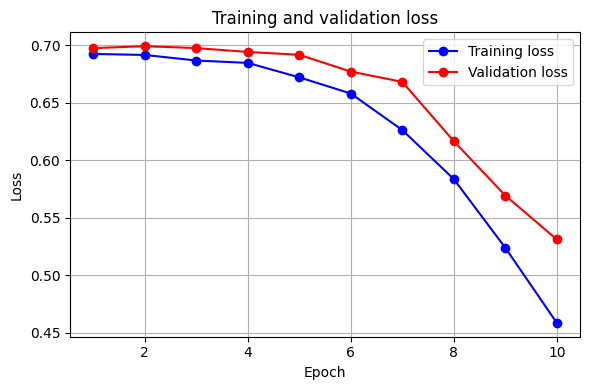

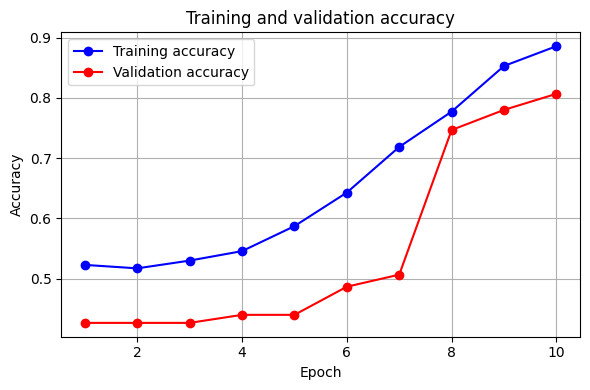

<- Model default took 8.521110534667969ms



-> Model 5-epochs


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4896 - loss: 0.6841
Test accuracy: 0.5066666603088379
Test loss: 0.6822325587272644


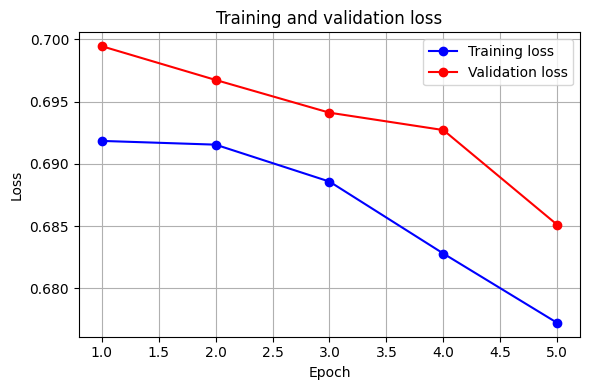

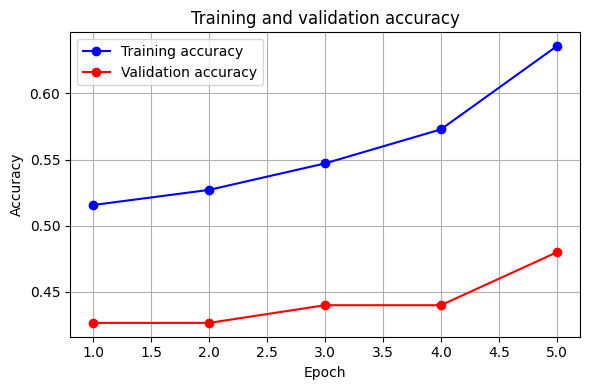

<- Model 5-epochs took 5.751171588897705ms



-> Model 20-epochs


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7660 - loss: 0.4944
Test accuracy: 0.7666666507720947
Test loss: 0.494430810213089


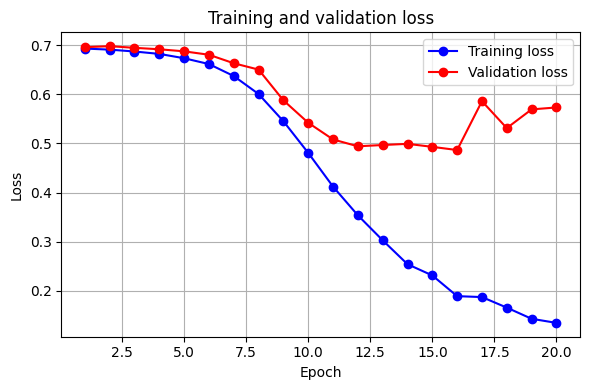

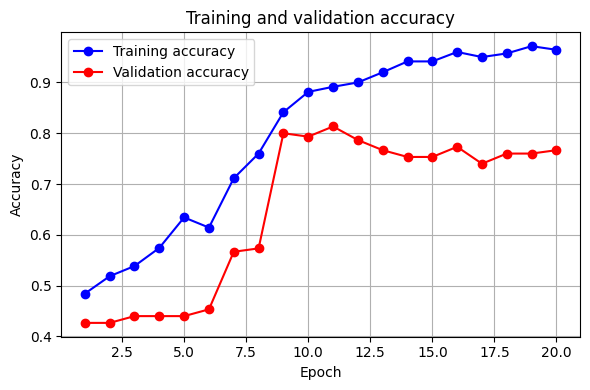

<- Model 20-epochs took 13.988719701766968ms



-> Model 16-batches


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7767 - loss: 0.4722 
Test accuracy: 0.7599999904632568
Test loss: 0.46708089113235474


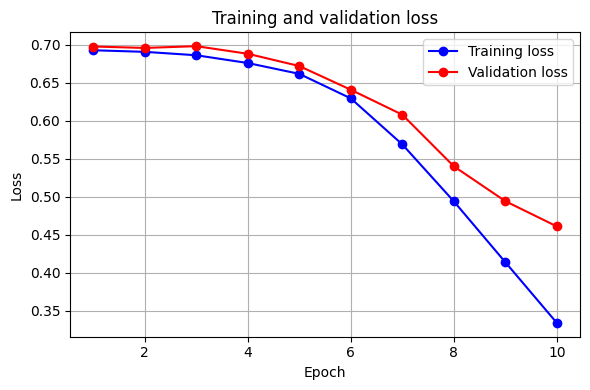

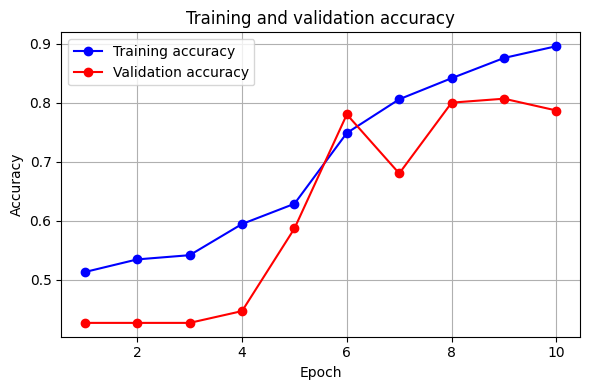

<- Model 16-batches took 11.94399619102478ms



-> Model 64-batches


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6832 - loss: 0.6488
Test accuracy: 0.6866666674613953
Test loss: 0.6464946269989014


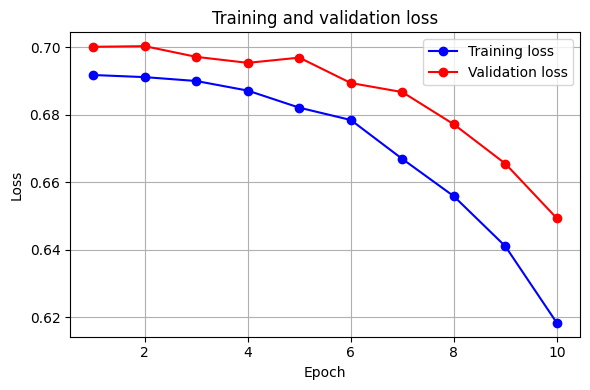

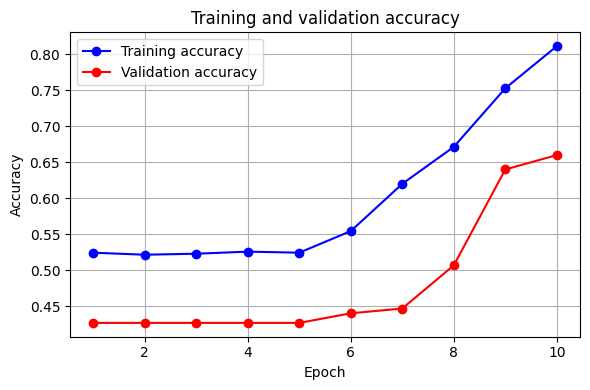

<- Model 64-batches took 6.796569585800171ms



-> Model model_a


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,920,197 (7.32 MB)

 Trainable params: 640,065 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,280,132 (4.88 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5920 - loss: 0.6708
Test accuracy: 0.6133333444595337
Test loss: 0.6682062745094299


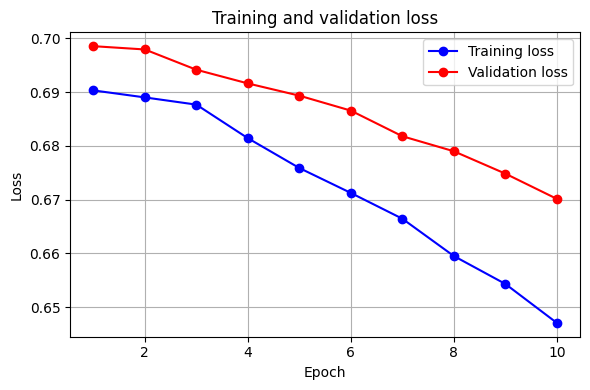

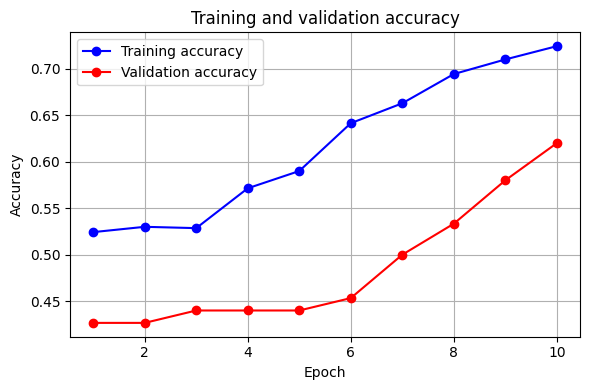

<- Model model_a took 8.04135799407959ms



-> Model model_c


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,957,829 (7.47 MB)

 Trainable params: 652,609 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,305,220 (4.98 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7869 - loss: 0.4226
Test accuracy: 0.7733333110809326
Test loss: 0.43317854404449463


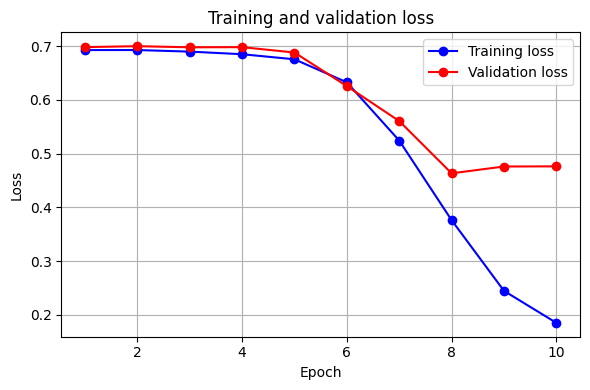

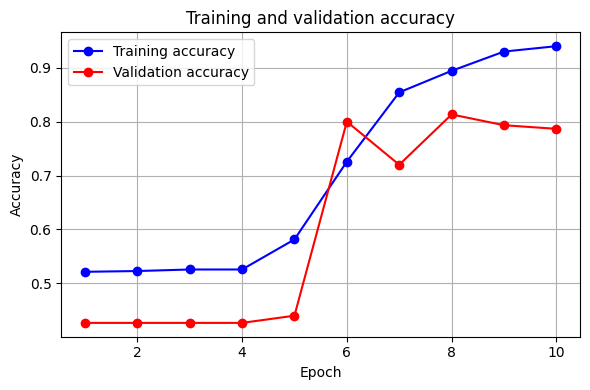

<- Model model_c took 8.84511113166809ms



-> Model 1d_cnn


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,969,733 (7.51 MB)

 Trainable params: 656,577 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,313,156 (5.01 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8154 - loss: 0.3658
Test accuracy: 0.8199999928474426
Test loss: 0.40124428272247314


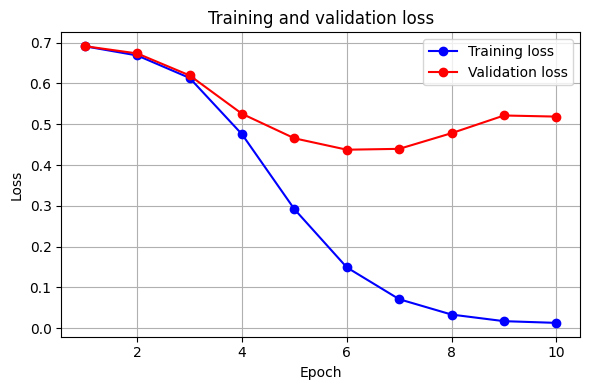

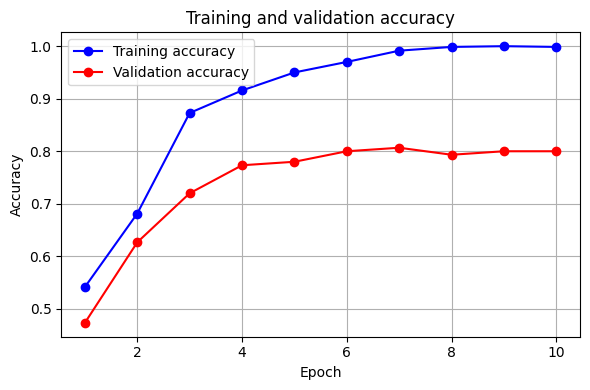

<- Model 1d_cnn took 10.319951295852661ms



-> Model tanh


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7572 - loss: 0.5121
Test accuracy: 0.753333330154419
Test loss: 0.501906156539917


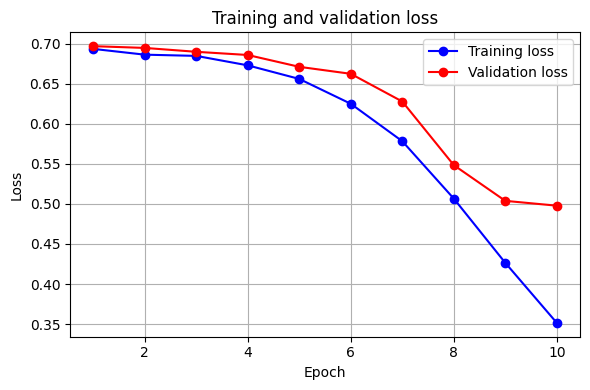

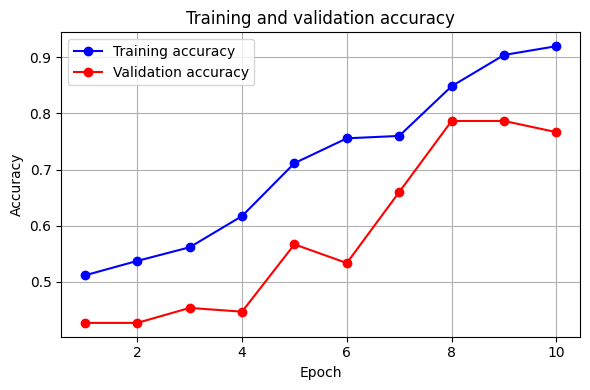

<- Model tanh took 7.986170291900635ms



-> Model hinge


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4607 - loss: 1.0333
Test accuracy: 0.47333332896232605
Test loss: 1.0138880014419556


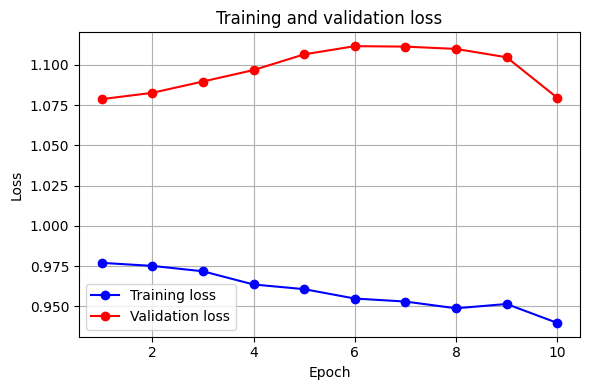

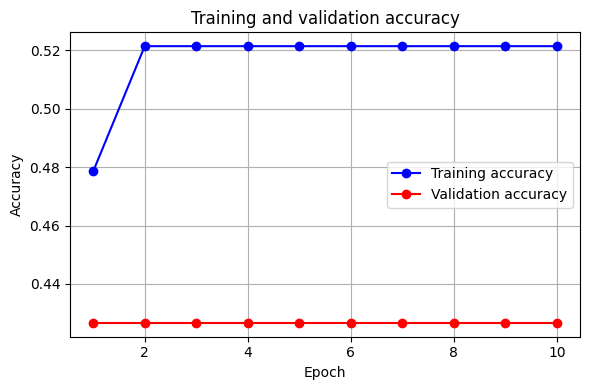

<- Model hinge took 8.014772176742554ms



-> Model sgd


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,288,452 (4.92 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 644,227 (2.46 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4607 - loss: 0.6972
Test accuracy: 0.47333332896232605
Test loss: 0.6960552334785461


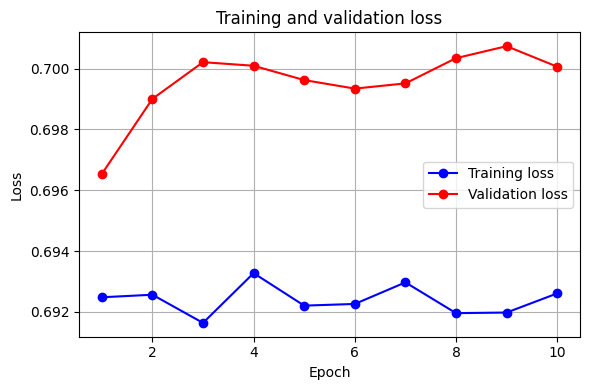

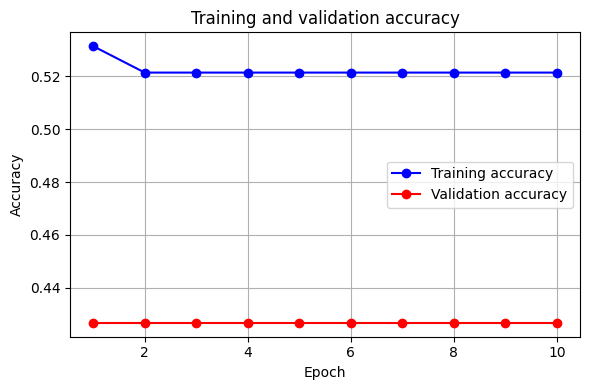

<- Model sgd took 5.37743353843689ms



-> Model sgd


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,288,452 (4.92 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 644,227 (2.46 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4607 - loss: 0.6970
Test accuracy: 0.47333332896232605
Test loss: 0.6955949068069458


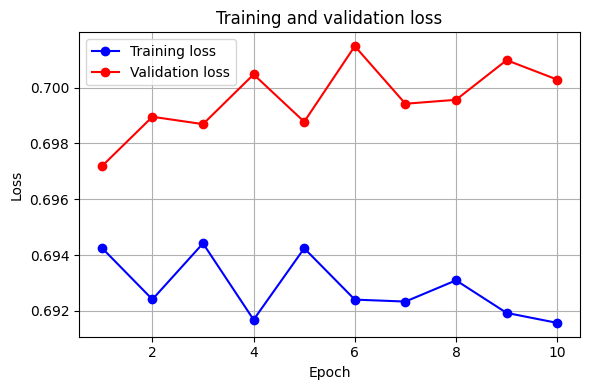

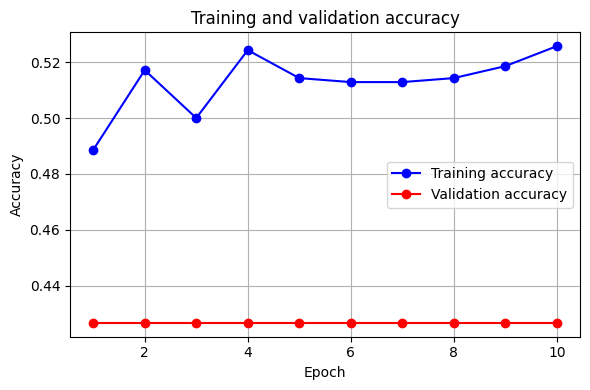

<- Model sgd took 6.9287333488464355ms



[{'name': 'default', 'time': 8.521110534667969, 'loss': 0.5426415801048279, 'acc': 0.7333333492279053}, {'name': '5-epochs', 'time': 5.751171588897705, 'loss': 0.6822325587272644, 'acc': 0.5066666603088379}, {'name': '20-epochs', 'time': 13.988719701766968, 'loss': 0.494430810213089, 'acc': 0.7666666507720947}, {'name': '16-batches', 'time': 11.94399619102478, 'loss': 0.46708089113235474, 'acc': 0.7599999904632568}, {'name': '64-batches', 'time': 6.796569585800171, 'loss': 0.6464946269989014, 'acc': 0.6866666674613953}, {'name': 'model_a', 'time': 8.04135799407959, 'loss': 0.6682062745094299, 'acc': 0.6133333444595337}, {'name': 'model_c', 'time': 8.84511113166809, 'loss': 0.43317854404449463, 'acc': 0.7733333110809326}, {'name': '1d_cnn', 'time': 10.319951295852661, 'loss': 0.40124428272247314, 'acc': 0.8199999928474426}, {'name': 'tanh', 'time': 7.986170291900635, 'loss': 0.501906156539917, 'acc': 0.753333330154419}, {'name': 'hinge', 'time':

In [7]:
run("default")

# Různé počty epoch
## reference: 10 epochs
## default

## zda se model učí už na začátku.
run("5-epochs", epochs=5)

## zda začne přeučení (val_loss začne růst).
run("20-epochs", epochs=20)

# Různé počty batch_size
## reference: 32 batches
## default

## menší batch → více update kroků, často lepší generalizace, ale pomalejší.
run("16-batches", batch_size=16)

## větší batch → rychlejší epochy, ale model se může učit hůř.
run("64-batches", batch_size=64)

# Různý počet vrstev
## Model A (velmi jednoduchý): Dense(1, sigmoid)
run("model_a", extra_layers=[])

## Model B (střední): Dense(64, relu) → Dense(1, sigmoid)
## default

## Model C (složitější): Dense(128, relu) → Dense(64, relu) → Dense(1, sigmoid)
run("model_c", extra_layers=[layers.Dense(64, activation=default_activation), layers.Dense(128, activation=default_activation)])

# Různá konfigurace vrstev
## Konfigurace 1 (baseline): GlobalAveragePooling
## default

## Konfigurace 2 (1D CNN): Conv1D(64, kernel_size=3, activation=relu) → GlobalMaxPooling1D
run("1d_cnn", main_layers=[layers.Conv1D(64, kernel_size=3, activation=default_activation), layers.GlobalMaxPooling1D()])

# Různé aktivační funkce
## Konfigurace 1 (baseline): ReLU
## default

## Konfigurace 2: Tanh
run("tanh", activation="tanh")

# Různé ztrátové funkce
## Konfigurace 1 (baseline): binary_crossentropy
## default

## Konfigurace 2: hinge
run("hinge", loss="hinge")

# Různé optimalizační techniky
## Adam (baseline).
## default

## SGD s momentum
run("sgd", optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9))

## RMSprop
run("sgd", optimizer=keras.optimizers.RMSprop(learning_rate=0.001))


print(model_data)

In [8]:
results = pd.DataFrame(model_data)
results

,name,time,loss,acc
0,default,8.521111,0.542642,0.733333
1,5-epochs,5.751172,0.682233,0.506667
2,20-epochs,13.988720,0.494431,0.766667
3,16-batches,11.943996,0.467081,0.760000
4,64-batches,6.796570,0.646495,0.686667
5,model_a,8.041358,0.668206,0.613333
6,model_c,8.845111,0.433179,0.773333
7,1d_cnn,10.319951,0.401244,0.820000
8,tanh,7.986170,0.501906,0.753333
9,hinge,8.014772,1.013888,0.473333


In [9]:
print(results)
results.to_csv("model_results.csv", index=False)

          name       time      loss       acc
0      default   8.521111  0.542642  0.733333
1     5-epochs   5.751172  0.682233  0.506667
2    20-epochs  13.988720  0.494431  0.766667
3   16-batches  11.943996  0.467081  0.760000
4   64-batches   6.796570  0.646495  0.686667
5      model_a   8.041358  0.668206  0.613333
6      model_c   8.845111  0.433179  0.773333
7       1d_cnn  10.319951  0.401244  0.820000
8         tanh   7.986170  0.501906  0.753333
9        hinge   8.014772  1.013888  0.473333
10         sgd   5.377434  0.696055  0.473333
11         sgd   6.928733  0.695595  0.473333
